# Assignment 3 - 02477 Bayesian Machine Learning

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random
import seaborn as snb

In [2]:
# Load data
data = jnp.load('./data_assignment3.npz')
x, y = data['x'], data['t']
print(x.shape)
print(y.shape)

(200,)
(200,)


In [3]:
xt = jnp.vstack((x, jnp.ones(200,))).T
print(xt.shape)

(200, 2)


> Task 1.1: Marginalize out each $z_n$ from the joint model in equation (7)

$$
K = \mathcal{N}(v|0,\tau^2I)\mathcal{N}(w_0|0,\tau^2I)\mathcal{N}(w_1|0,\tau^2I)\mathcal{N}_{+}(\sigma_0|0,1)\mathcal{N}_{+}(\sigma_1|0,1)\mathcal{N}_{+}(\tau|0,1)
$$

$$
p(y,z,v,w_0,w_1,\sigma_0,\sigma_1) = \left[\prod_{n=1}^{N}\mathcal{N}(y_n|w_{z_n}^Tx_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n))\right]\cdot K
$$

$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = \sum_{z_1\in{0,1}}\sum_{z_2\in{0,1}}...\sum_{z_N\in{0,1}}p(y,z,v,w_0,w_1,\sigma_0,\sigma_1)
$$

$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = \sum_{z_1\in{0,1}}\sum_{z_2\in{0,1}}...\sum_{z_N\in{0,1}}\left[\prod_{n=1}^{N}\mathcal{N}(y_n|w_{z_n}^T x_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n))\right]\cdot K
$$

$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = K \cdot \sum_{z_1\in{0,1}}\sum_{z_2\in{0,1}}...\sum_{z_N\in{0,1}}\left[\prod_{n=1}^{N}\mathcal{N}(y_n|w_{z_n}^T x_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n))\right]
$$


$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = K\cdot \left[\prod_{n=1}^{N}\sum_{z_n\in{0,1}}\mathcal{N}(y_n|w_{z_n}^T x_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n))\right]
$$

For each value of n:
$$
\sum_{z_n\in{0,1}}\mathcal{N}(y_n|w_{z_n}^T x_n, \sigma_{z_n}^2)Ber(z_n| \sigma(v^Tx_n)) = (1-\sigma(v^Tx_n))\mathcal{N}(y_n|w_0^T x_n, \sigma_0^2) + \sigma(v^Tx_n)\mathcal{N}(y_n|w_1^T x_n, \sigma_1^2)
$$

Then we arrive at:
$$
p(y,v,w_0,w_1,\sigma_0,\sigma_1) = \left[\prod_{n=1}^{N}\left((1-\sigma(v^Tx_n))\mathcal{N}(y_n|w_0^T x_n, \sigma_0^2) + \sigma(v^Tx_n)\mathcal{N}(y_n|w_1^T x_n, \sigma_1^2)\right)\right]\cdot K
$$



> Task 1.2: Implement a Python function to evaluate the marginalized log joint distribution

In [14]:
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v)
npdf = lambda x, m, v: jnp.exp(log_npdf(x, m, v))
log_half_npdf = lambda x, m, v: jnp.log(2) -0.5*(x-m)**2/(v) - 0.5*jnp.log(2*jnp.pi*v)
sigmoid = lambda x: 1./(1 + jnp.exp(-x))


def log_joint(theta):

    w0 = theta[:2]
    w1 = theta[2:4]
    v = theta[4:6]
    tau = theta[6]
    sig02 = theta[7]
    sig12 = theta[8]

    sig0 = jnp.sqrt(sig02)
    sig1 = jnp.sqrt(sig12)
    # w0, w1, v are vectors
    
    sigs = sigmoid(v@xt.T)

    # We need to sample yn
    nw0 = jnp.sum(log_npdf(w0, 0, tau**2))
    nw1 = jnp.sum(log_npdf(w1, 0, tau**2))
    nv = jnp.sum(log_npdf(v, 0, tau**2))

    ntau = log_half_npdf(tau, 0, 1)
    nsig0 = log_half_npdf(sig0, 0, 1)
    nsig1 = log_half_npdf(sig1, 0, 1)

    likelihood = jnp.sum(jnp.log((1-sigs)*npdf(y, w0@xt.T, sig02) + sigs*npdf(y,w1@xt.T,sig12)))

    return likelihood + nw0 + nw1 + nv + ntau + nsig0 + nsig1


## 1.3

In [15]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau * random.normal(key_proposal,shape=(num_params, ))

        log_p_theta_star = log_target(theta_star)

        log_r = log_p_theta_star - log_p_theta

        A_k = jnp.minimum(1, jnp.exp(log_r))

        if random.uniform(key_accept) < A_k:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)         
        thetas.append(theta_next)


        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas

In [ ]:
num_iter = 20000
warm_up = int(0.5*num_iter)
theta_init = np.array([0., 0.,    # w0
                        0., 0.,    # w1
                        0., 0.,    # v
                        1.,        # tau (prior scale, must be > 0)
                        1.,        # sig02 (variance, must be > 0)
                        1.])       # sig12 (variance, must be > 0)
num_params = len(theta_init)

thetas = metropolis(log_joint, num_params, 0.3, num_iter=num_iter, theta_init=theta_init)

# get rid of warm-up samples
thetas = thetas[warm_up:, :]


Acceptance ratio: 0.00


Text(0.5, 0, 'Iterations')

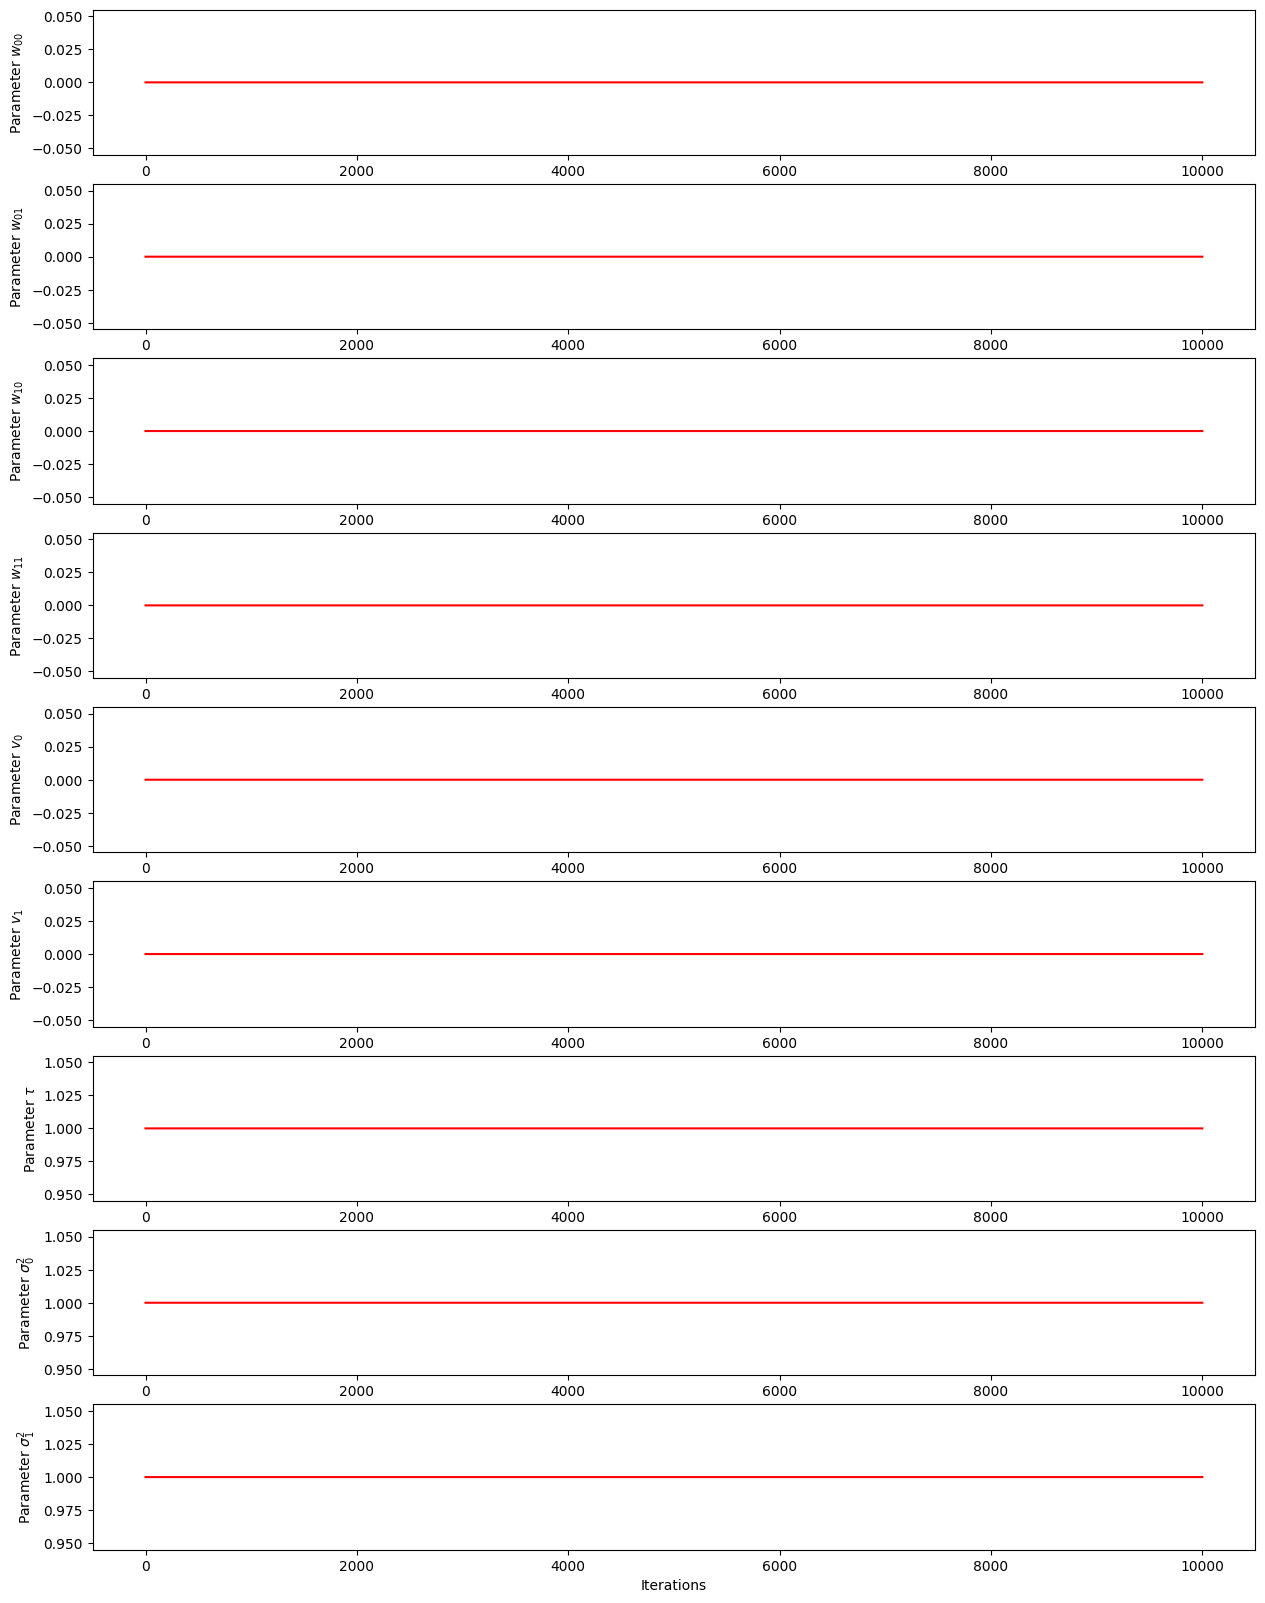

In [21]:
name_params = ['$w_{00}$', '$w_{01}$', '$w_{10}$', '$w_{11}$', '$v_0$', '$v_1$', '$\\tau$', '$\\sigma^2_0$', '$\\sigma^2_1$']
fig, axes = plt.subplots(num_params, 1, figsize=(15, 20))

for i in range(num_params):
    axes[i].plot(thetas[:, i], 'r-')
    axes[i].set(ylabel=f'Parameter {name_params[i]}')
axes[-1].set_xlabel('Iterations')